In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

import scienceplots 
plt.style.use(["science", "grid"])
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.titlesize": 15,
})

In [2]:
# load and inspect data
X_train = np.loadtxt('data/X_train.csv', delimiter=',').astype(float)
y_train = np.loadtxt('data/y_train.csv').astype(int)
X_test  = np.loadtxt('data/X_test.csv', delimiter=',').astype(float)
y_test  = np.loadtxt('data/y_test.csv').astype(int)
print(X_train.shape, y_train.shape,"\n",X_test.shape,y_train.shape)
X_train[:5,:4]

(33724, 16) (33724,) 
 (13901, 16) (33724,)


array([[-0.72724563, -0.60031718, -0.66578561,  1.49231172],
       [-0.74023116, -0.59516239, -0.65084755,  1.08008218],
       [-0.74369389, -0.6017803 , -0.67954147,  1.08720624],
       [-0.73197955, -0.60480744, -0.66515815,  1.74063909],
       [-0.73055738, -0.60145271, -0.66412419,  1.52568424]])

0: 0.521
1: 0.096
2: 0.253
3: 0.047
4: 0.084


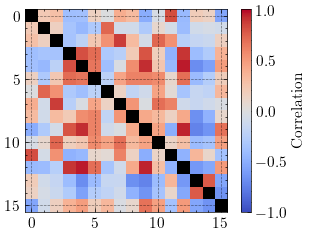

In [3]:
# 3.1: understanding the data
 
# class frequencies
for cl in np.unique(y_train):
    print(f"{cl}: {np.mean(y_train==cl).round(3)}")

# correlation plot
corr = np.corrcoef(X_train, rowvar=False)

plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")

# highlight correlations equal to 1 in black
mask = np.isclose(corr, 1.0)

plt.imshow(
    np.ma.masked_where(~mask, mask),
    cmap="gray_r",
    vmin=0,
    vmax=1
)

plt.show()

In [4]:
# 3.2.1 logistic regression

# initialize logistic reg class
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# in sample empirical risk
y_pred = model.predict(X_train)
print(f"In sample risk:     {np.mean(y_pred != y_train).round(3)}")

# out of sample empirical risk
y_pred = model.predict(X_test)
print(f"Out of sample risk: {np.mean(y_pred != y_test).round(3)}")

In sample risk:     0.149
Out of sample risk: 0.099


In [5]:
# 3.2.2 random forest with cross-validation

# hyperparameter grid
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_leaf": [1, 2, 5],
}

# 5-fold cross-validation
for n_estimators in [50,100,200]:


    # initialize random forest
    rf = RandomForestClassifier(
        random_state=67,
        n_estimators=n_estimators,
        n_jobs=1,
        oob_score=True
    )

    cv_split = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=67
    )

    cv = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=cv_split, # cross validation folds a.k.a. number of data-partitions
        scoring="accuracy", # accuracy = 1 - risk, where risk is calculated using 0-1 loss
        verbose=2, # printouts
        n_jobs=-1 # cpu parallelization
    )

    # only use training data for hyperparameter selection
    cv.fit(X_train, y_train)

    # best hyperparameters
    print("Best parameters:", cv.best_params_)
    print(f"Best CV risk:     {1 - cv.best_score_:.3f}")

    # best fitted random forest
    rf_best = cv.best_estimator_

    # in-sample empirical risk
    y_pred = rf_best.predict(X_train)
    print(f"In sample risk:   {np.mean(y_pred != y_train):.3f}")

    # out-of-bag empirical risk
    print(f"Out of bag error: {1 - rf_best.oob_score_:.3f}")

    # out-of-sample empirical risk
    y_pred = rf_best.predict(X_test)
    print(f"Out of sample risk: {np.mean(y_pred != y_test):.3f}\n")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1}
Best CV risk:     0.147
In sample risk:   0.107
Out of bag error: 0.147
Out of sample risk: 0.106

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1}
Best CV risk:     0.147
In sample risk:   0.107
Out of bag error: 0.146
Out of sample risk: 0.106

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1}
Best CV risk:     0.147
In sample risk:   0.106
Out of bag error: 0.146
Out of sample risk: 0.105



In [7]:
# 3.2.3 K-nearest neighbors with CV selection for K

# initialize
knn = KNeighborsClassifier()

cv_split = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=67
)

cv = GridSearchCV(
    knn,
    {"n_neighbors": range(1, 500)}, # limit K in the considered models
    cv=cv_split, # cross validation folds a.k.a. number of data-partitions
    scoring="accuracy", # accuracy = 1 - risk, where risk is calculated using 0-1 loss
    verbose=2, # printouts
    n_jobs=-1 # cpu parallelization
)

cv.fit(X_train, y_train)

print("Best k:", cv.best_params_["n_neighbors"])
print(f"Best CV risk: {1 - cv.best_score_:.3f}")

# best fitted KNN model
knn_best = cv.best_estimator_

# in-sample empirical risk
y_pred = knn_best.predict(X_train)
print(f"In sample risk: {np.mean(y_pred != y_train):.3f}")

# out-of-sample empirical risk
y_pred = knn_best.predict(X_test)
print(f"Out of sample risk: {np.mean(y_pred != y_test):.3f}")

Fitting 5 folds for each of 499 candidates, totalling 2495 fits
Best k: 24
Best CV risk: 0.150
In sample risk: 0.142
Out of sample risk: 0.102
